In [1]:
%matplotlib inline


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# IPL Match Outcome Forecast
This notebook builds a historical priors predictive model for the AIPL competition.
It uses time-series validation and static class priors to generate calibrated probability predictions.

## 1. Data Loading & Preprocessing

In [3]:
train_df_raw = pd.read_csv('train_bundle/train_IPL.csv',low_memory=False)
print("Train shape:", train_df_raw.shape)

match_cols = ['Match ID', 'Date', 'season', 'Venue', 'city', 'Bat First', 'Bat Second', 'toss_winner', 'toss_decision', 'match_won_by', 'result_type']
match_df = train_df_raw[match_cols].drop_duplicates(subset=['Match ID']).set_index('Match ID')

# Calculate innings totals
inn1 = train_df_raw[train_df_raw['Innings'] == 1].groupby('Match ID')['Innings Runs'].max().rename('inn1_runs')
inn2 = train_df_raw[train_df_raw['Innings'] == 2].groupby('Match ID')['Innings Runs'].max().rename('inn2_runs')
inn1_w = train_df_raw[train_df_raw['Innings'] == 1].groupby('Match ID')['Innings Wickets'].max().rename('inn1_wickets')
inn2_w = train_df_raw[train_df_raw['Innings'] == 2].groupby('Match ID')['Innings Wickets'].max().rename('inn2_wickets')

match_df = match_df.join([inn1, inn2, inn1_w, inn2_w])

# Filter out tie and no result
match_df = match_df[~match_df['result_type'].isin(['tie', 'no result'])].copy()

Train shape: (272704, 38)


## 2. Exploratory Data Analysis (EDA)

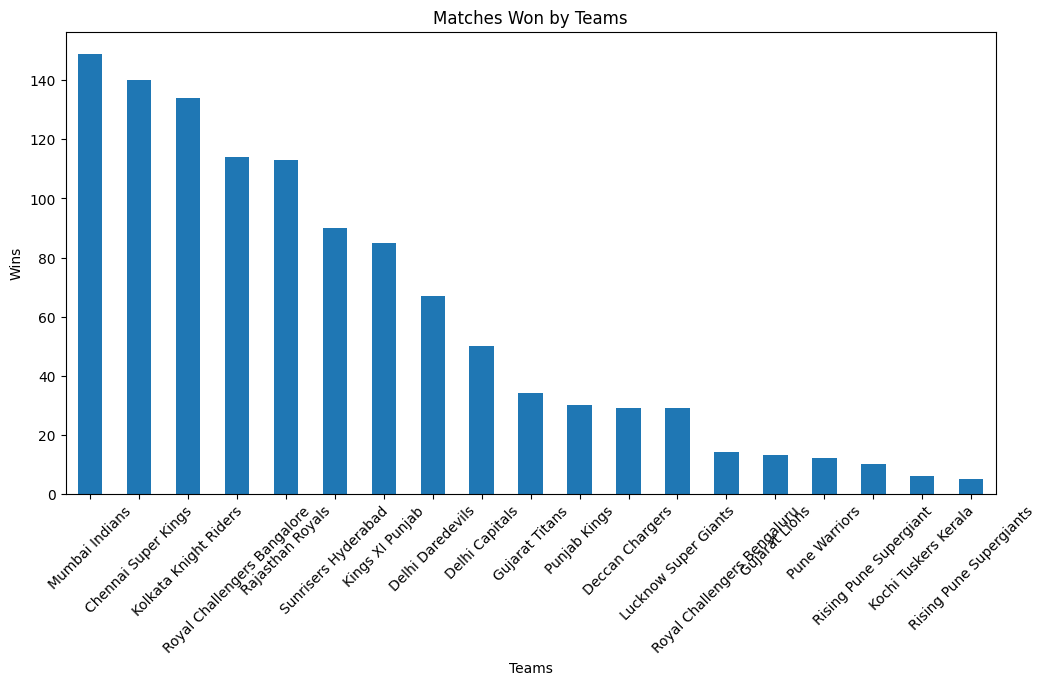

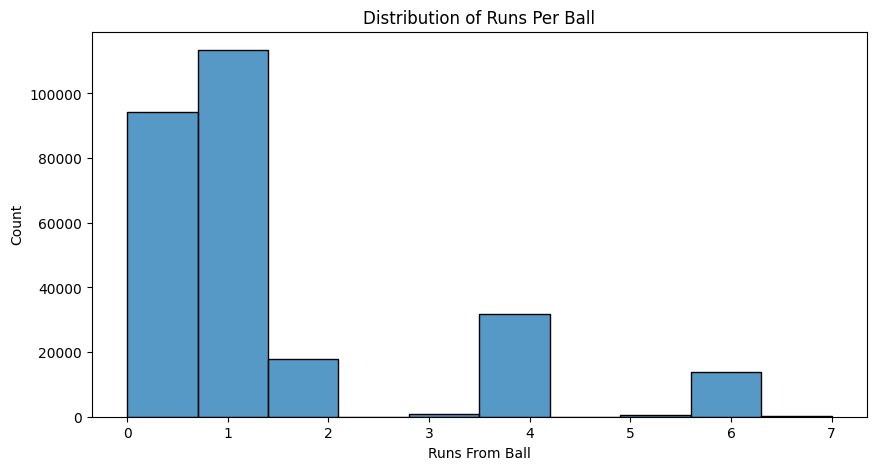

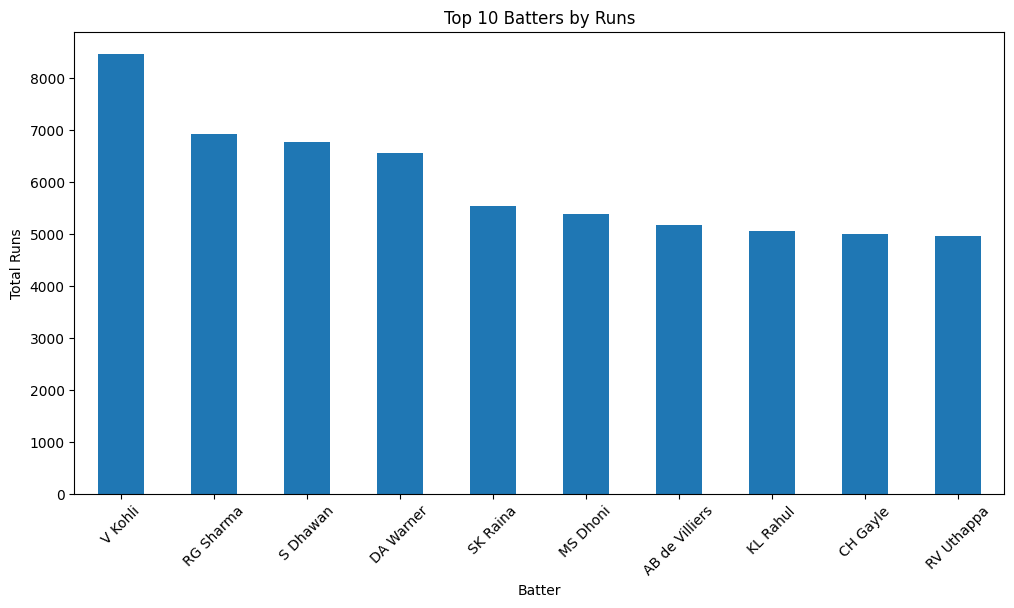

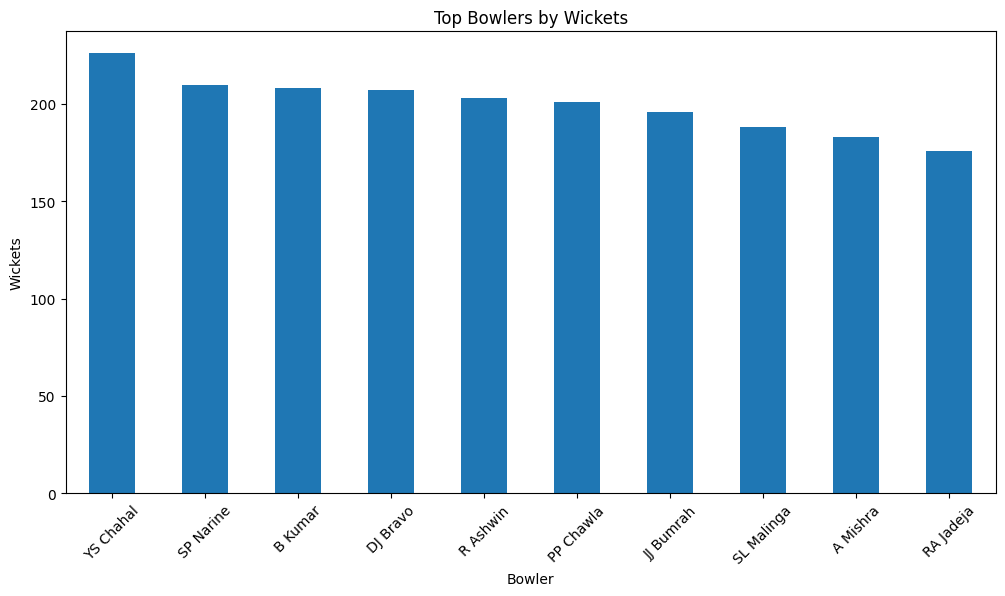

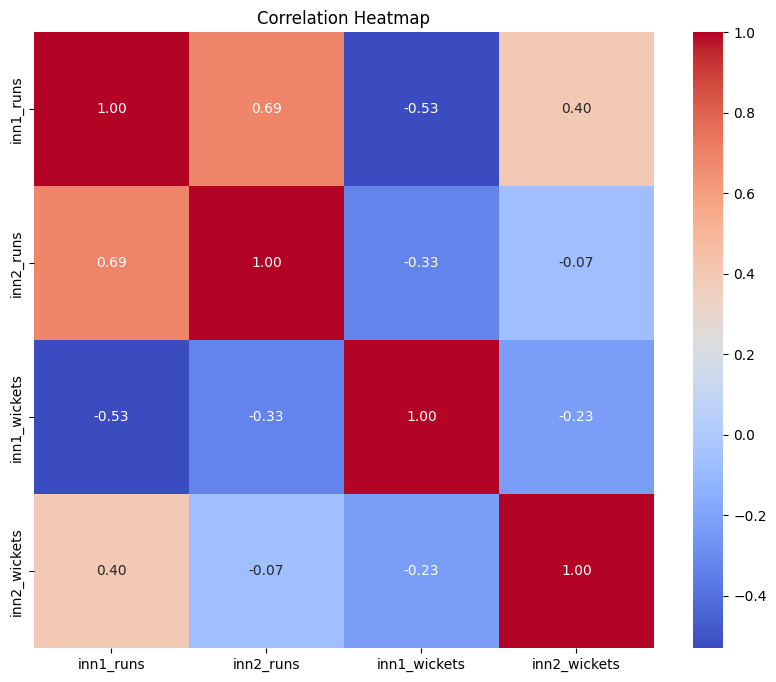

In [4]:
# Top Teams by Wins
plt.figure(figsize=(12,6))
match_df['match_won_by'].value_counts().plot(kind='bar')
plt.title('Matches Won by Teams')
plt.xlabel('Teams')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.show()

# Run Distribution
plt.figure(figsize=(10,5))
sns.histplot(train_df_raw['Runs From Ball'], bins=10)
plt.title('Distribution of Runs Per Ball')
plt.show()

# Top Batters by Total Runs
top_batters = (
    train_df_raw.groupby('Batter')['Batter Runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
top_batters.plot(kind='bar')
plt.title('Top 10 Batters by Runs')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.show()

# Top Bowlers by Wickets
top_bowlers = (
    train_df_raw[train_df_raw['Wicket'] == 1].groupby('Bowler')['Wicket']
    .count()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
top_bowlers.plot(kind='bar')
plt.title('Top Bowlers by Wickets')
plt.ylabel('Wickets')
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap for Innings scores
plt.figure(figsize=(10,8))
corr_cols = ['inn1_runs', 'inn2_runs', 'inn1_wickets', 'inn2_wickets']
sns.heatmap(match_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 3. Target Generation
We derive the 4-class target label (A_small, A_big, B_small, B_big) where A = Bat First and B = Bat Second.

In [5]:
def get_label(row):
    winner = row['match_won_by']
    bat_first = row['Bat First']
    bat_second = row['Bat Second']
    
    if winner == bat_first:
        runs_margin = row['inn1_runs'] - row['inn2_runs']
        if pd.isna(runs_margin): return np.nan
        return 'A_big' if runs_margin > 20 else 'A_small'
    elif winner == bat_second:
        wickets_margin = 10 - row['inn2_wickets']
        if pd.isna(wickets_margin): return np.nan
        return 'B_big' if wickets_margin >= 6 else 'B_small'
    else:
        return np.nan

match_df['target'] = match_df.apply(get_label, axis=1)
match_df = match_df.dropna(subset=['target']).copy()

## 4. Time-Series Train/Validation Split

In [6]:
# Sort chronologically to prevent peeking into the future
match_df['Date'] = pd.to_datetime(match_df['Date'])
match_df = match_df.sort_values('Date').reset_index(drop=True)

# Use the last 15% of historical matches as our validation pool
split_idx = int(len(match_df) * 0.85)
train_df = match_df.iloc[:split_idx].copy()
val_df = match_df.iloc[split_idx:].copy()

print(f"Training on {len(train_df)} matches | Validating on {len(val_df)} matches\n")

Training on 955 matches | Validating on 169 matches



## 5. Calculate Historical Class Priors

In [7]:
# Compute how often each of the 4 outcome classes actually occurs in our training set
class_priors = train_df['target'].value_counts(normalize=True)

p_A_small = class_priors.get('A_small', 0.25)
p_A_big   = class_priors.get('A_big', 0.25)
p_B_small = class_priors.get('B_small', 0.25)
p_B_big   = class_priors.get('B_big', 0.25)

print("--- Your Calculated Historical Priors ---")
print(f"A_small (Team A tight win): {p_A_small:.4f}")
print(f"A_big   (Team A blowout):   {p_A_big:.4f}")
print(f"B_small (Team B tight win): {p_B_small:.4f}")
print(f"B_big   (Team B blowout):   {p_B_big:.4f}\n")

--- Your Calculated Historical Priors ---
A_small (Team A tight win): 0.2073
A_big   (Team A blowout):   0.2398
B_small (Team B tight win): 0.1916
B_big   (Team B blowout):   0.3613



## 6. Manual Log Loss Validation Check

In [8]:
def calculate_manual_log_loss(y_true_series, p_A_sm, p_A_bg, p_B_sm, p_B_bg):
    losses = []
    for actual in y_true_series:
        if actual == 'A_small':
            losses.append(-np.log(p_A_sm))
        elif actual == 'A_big':
            losses.append(-np.log(p_A_bg))
        elif actual == 'B_small':
            losses.append(-np.log(p_B_sm))
        elif actual == 'B_big':
            losses.append(-np.log(p_B_bg))
    return np.mean(losses)

val_loss = calculate_manual_log_loss(val_df['target'], p_A_small, p_A_big, p_B_small, p_B_big)
print(f"Validation Mean Columnwise Log Loss: {val_loss:.4f}")

Validation Mean Columnwise Log Loss: 1.3642


## 7. Generating the Competition Submission

In [9]:
try:
    # 1. FIXED INPUT PATH: Using the absolute Kaggle path
    sub_template = pd.read_csv('train_bundle/sample_submission.csv')

    submission = sub_template.copy()
    submission['A_small'] = p_A_small
    submission['A_big'] = p_A_big
    submission['B_small'] = p_B_small
    submission['B_big'] = p_B_big

    # 2. FIXED OUTPUT PATH: Added the actual file name
    submission.to_csv('submission.csv', index=False)
    
    print("\n--- Success! 'submission.csv' generated cleanly. ---")
    print(submission.head())
    
except FileNotFoundError:
    print("\nNote: Input file not found. Check your file path!")


--- Success! 'submission.csv' generated cleanly. ---
  match_id  A_small     A_big   B_small     B_big
0  1473488  0.20733  0.239791  0.191623  0.361257
1  1473489  0.20733  0.239791  0.191623  0.361257
2  1473490  0.20733  0.239791  0.191623  0.361257
3  1473491  0.20733  0.239791  0.191623  0.361257
4  1473492  0.20733  0.239791  0.191623  0.361257
